# Bayesian Sensitivity Analysis — v1 Model

Re-runs the sequential v1 model under a panel of alternative prior specifications and compares the resulting posteriors and forecasts. The goal is to answer: *if I had chosen different prior scales (or shifted the mean), would my conclusions about $\mu_g$, $\sigma_r$, and the forecast change?*

**Scenarios:**

| Name | Prior family | $\sigma_r$ | $\mu_g$ (mean) | $\mu_g$ (sd) | $\sigma_g$ | $\sigma_{\text{batch}}$ |
|---|---|---|---|---|---|---|
| `very_tight`    | HalfNormal | 0.010 | 0.00  | 0.010 | HN(0.010) | HN(0.010) |
| `tight`         | HalfNormal | 0.025 | 0.00  | 0.025 | HN(0.025) | HN(0.025) |
| `default`       | HalfNormal | 0.050 | 0.00  | 0.050 | HN(0.050) | HN(0.050) |
| `loose`         | HalfNormal | 0.100 | 0.00  | 0.100 | HN(0.100) | HN(0.100) |
| `extra_loose`   | HalfNormal | 0.200 | 0.00  | 0.200 | HN(0.200) | HN(0.200) |
| `mu_g_positive` | HalfNormal | 0.050 | +0.03 | 0.050 | HN(0.050) | HN(0.050) |
| `mu_g_negative` | HalfNormal | 0.050 | -0.03 | 0.050 | HN(0.050) | HN(0.050) |
| `hc_default`    | HalfCauchy | 0.050 | 0.00  | 0.050 | HC(0.050) | HC(0.050) |

HalfCauchy has heavier tails than HalfNormal at the same scale — it assigns more prior mass to large variance values while still centering near zero. `hc_default` uses the same scale (0.05) as `default` so any difference is purely from the tail shape.

Each scenario trains all batches sequentially. Completed traces are cached to disk and skipped on re-run.

In [64]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import os
import json
import seaborn as sns

In [65]:
race_data = pd.read_csv("race_data.csv")
drop_data = pd.read_csv("drop_data.csv")
drop_data['Datetime'] = pd.to_datetime(drop_data['Datetime'])

with open("mapping_dicts.json", "r") as f:
    mappings = json.load(f)
race_to_id  = mappings['race_to_id']
batch_to_id = mappings['batch_to_id']
id_to_race  = {int(k): v for k, v in mappings['id_to_race'].items()}
id_to_batch = {int(k): v for k, v in mappings['id_to_batch'].items()}

model_data = drop_data.dropna(subset=['this_batch_dem_proportion']).copy()
n_races = len(race_data)
batches = sorted(model_data['batch_id'].unique())
baseline_array = race_data.sort_values('race_id')['baseline_dem_proportion'].values

print(f'n_races: {n_races} | n_batches: {len(batches)}')

n_races: 13 | n_batches: 24


In [66]:
SENSITIVITY_CONFIGS = {
    'very_tight':    {'sigma_r': 0.010, 'mu_g_mu':  0.00, 'mu_g_sigma': 0.010, 'sigma_g': 0.010, 'sigma_batch': 0.010, 'dist': 'halfnormal'},
    'tight':         {'sigma_r': 0.025, 'mu_g_mu':  0.00, 'mu_g_sigma': 0.025, 'sigma_g': 0.025, 'sigma_batch': 0.025, 'dist': 'halfnormal'},
    'default':       {'sigma_r': 0.050, 'mu_g_mu':  0.00, 'mu_g_sigma': 0.050, 'sigma_g': 0.050, 'sigma_batch': 0.050, 'dist': 'halfnormal'},
    'loose':         {'sigma_r': 0.100, 'mu_g_mu':  0.00, 'mu_g_sigma': 0.100, 'sigma_g': 0.100, 'sigma_batch': 0.100, 'dist': 'halfnormal'},
    'extra_loose':   {'sigma_r': 0.200, 'mu_g_mu':  0.00, 'mu_g_sigma': 0.200, 'sigma_g': 0.200, 'sigma_batch': 0.200, 'dist': 'halfnormal'},
    'mu_g_positive': {'sigma_r': 0.050, 'mu_g_mu':  0.03, 'mu_g_sigma': 0.050, 'sigma_g': 0.050, 'sigma_batch': 0.050, 'dist': 'halfnormal'},
    'mu_g_negative': {'sigma_r': 0.050, 'mu_g_mu': -0.03, 'mu_g_sigma': 0.050, 'sigma_g': 0.050, 'sigma_batch': 0.050, 'dist': 'halfnormal'},
    'hc_default':    {'sigma_r': 0.050, 'mu_g_mu':  0.00, 'mu_g_sigma': 0.050, 'sigma_g': 0.050, 'sigma_batch': 0.050, 'dist': 'halfcauchy'},
}

config_names = list(SENSITIVITY_CONFIGS.keys())
print('Scenarios to run:', config_names)

Scenarios to run: ['very_tight', 'tight', 'default', 'loose', 'extra_loose', 'mu_g_positive', 'mu_g_negative', 'hc_default']


## Train sequentially under each prior scenario

In [67]:
def build_v1_model(cfg, obs_race_idx, obs_b_rt, obs_baseline, n_races):
    dist = cfg.get('dist', 'halfnormal')
    with pm.Model() as model:
        if dist == 'halfcauchy':
            sigma_r     = pm.HalfCauchy('sigma_r',     beta=cfg['sigma_r'])
            sigma_g     = pm.HalfCauchy('sigma_g',     beta=cfg['sigma_g'])
            sigma_batch = pm.HalfCauchy('sigma_batch', beta=cfg['sigma_batch'])
        else:
            sigma_r     = pm.HalfNormal('sigma_r',     sigma=cfg['sigma_r'])
            sigma_g     = pm.HalfNormal('sigma_g',     sigma=cfg['sigma_g'])
            sigma_batch = pm.HalfNormal('sigma_batch', sigma=cfg['sigma_batch'])

        mu_g = pm.Normal('mu_g', mu=cfg['mu_g_mu'], sigma=cfg['mu_g_sigma'])

        z_r = pm.Normal('z_r', mu=0.0, sigma=1.0, shape=n_races)
        s_r = pm.Deterministic('s_r', z_r * sigma_r)
        z_g = pm.Normal('z_g', mu=0.0, sigma=1.0)
        s_g = pm.Deterministic('s_g', mu_g + (z_g * sigma_g))

        expected_b = s_r[obs_race_idx] + s_g + obs_baseline
        pm.Normal('b_rt', mu=expected_b, sigma=sigma_batch, observed=obs_b_rt)
    return model


trace_root = 'v1_sensitivity_traces'
os.makedirs(trace_root, exist_ok=True)

sensitivity_traces = {name: {} for name in config_names}

for name, cfg in SENSITIVITY_CONFIGS.items():
    print(f'\n==== Scenario: {name} | dist: {cfg["dist"]} ====')
    for current_batch in batches:
        fp = os.path.join(trace_root, name, f'trace_batch_{current_batch}.nc')
        if os.path.exists(fp):
            sensitivity_traces[name][current_batch] = az.from_netcdf(fp)
            print(f'  batch {current_batch:2}: loaded from disk')
            continue

        cumulative_drops = model_data[model_data['batch_id'] <= current_batch]
        obs_race_idx = cumulative_drops['race_id'].values
        obs_b_rt     = cumulative_drops['this_batch_dem_proportion'].values
        obs_baseline = cumulative_drops['baseline_dem_proportion'].values

        model = build_v1_model(cfg, obs_race_idx, obs_b_rt, obs_baseline, n_races)
        with model:
            trace = pm.sample(draws=2000, tune=1000, chains=4, cores=4,
                              target_accept=0.99, progressbar=False, random_seed=42)
        sensitivity_traces[name][current_batch] = trace

        os.makedirs(os.path.join(trace_root, name), exist_ok=True)
        if os.path.exists(fp):
            os.remove(fp)
        trace.to_netcdf(fp)
        print(f'  batch {current_batch:2}: sampled + saved')

print('\nAll scenarios done.')


==== Scenario: very_tight | dist: halfnormal ====


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_r, sigma_g, sigma_batch, mu_g, z_r, z_g]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 50 seconds.
There were 384 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


  batch  0: sampled + saved


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_r, sigma_g, sigma_batch, mu_g, z_r, z_g]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 32 seconds.


  batch  1: sampled + saved


...

  batch 21: sampled + saved


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_r, sigma_g, sigma_batch, mu_g, z_r, z_g]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 70 seconds.
There were 41 divergences after tuning. Increase `target_accept` or reparameterize.


  batch 22: sampled + saved


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_r, sigma_g, sigma_batch, mu_g, z_r, z_g]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 78 seconds.
There were 53 divergences after tuning. Increase `target_accept` or reparameterize.


  batch 23: sampled + saved

All scenarios done.


In [68]:
## Run this cell instead of sa-train to skip MCMC and load saved traces from disk.
## Only loads scenarios listed in config_names (very_loose excluded).
sensitivity_traces = {name: {} for name in config_names}

for name in config_names:
    trace_dir = os.path.join('v1_sensitivity_traces', name)
    for batch in batches:
        fp = os.path.join(trace_dir, f'trace_batch_{batch}.nc')
        sensitivity_traces[name][batch] = az.from_netcdf(fp)
    print(f'Loaded {len(batches)} traces <- {trace_dir}/')

print('Done.')

Loaded 24 traces <- v1_sensitivity_traces\very_tight/
Loaded 24 traces <- v1_sensitivity_traces\tight/
Loaded 24 traces <- v1_sensitivity_traces\default/
Loaded 24 traces <- v1_sensitivity_traces\loose/
Loaded 24 traces <- v1_sensitivity_traces\extra_loose/
Loaded 24 traces <- v1_sensitivity_traces\mu_g_positive/
Loaded 24 traces <- v1_sensitivity_traces\mu_g_negative/
Loaded 24 traces <- v1_sensitivity_traces\hc_default/
Done.


## Sampling diagnostics across scenarios

In [69]:
check_vars = ['mu_g', 'sigma_g', 'sigma_r', 'sigma_batch', 's_g']
rows = []
for name in config_names:
    for batch in batches:
        s = az.summary(sensitivity_traces[name][batch], var_names=check_vars)
        rows.append({
            'scenario':    name,
            'batch':       batch,
            'max_rhat':    s['r_hat'].max(),
            'min_ess_blk': int(s['ess_bulk'].min()),
            'min_ess_tl':  int(s['ess_tail'].min()),
        })
conv = pd.DataFrame(rows)
# Per-scenario worst-case across batches:
worst = conv.groupby('scenario').agg(
    max_rhat_overall   = ('max_rhat',    'max'),
    min_ess_bulk_overall = ('min_ess_blk', 'min'),
    min_ess_tail_overall = ('min_ess_tl',  'min'),
)
display(worst)
print('Detailed per-batch convergence (first few rows):')
display(conv.head(10))

,max_rhat_overall,min_ess_bulk_overall,min_ess_tail_overall
scenario,,,
default,1.00,224,183
extra_loose,1.01,378,293
hc_default,1.11,26,11
loose,1.01,484,460
mu_g_negative,1.08,39,25
mu_g_positive,1.02,326,239
tight,1.05,73,24
very_tight,1.05,59,32


Detailed per-batch convergence (first few rows):


,scenario,batch,max_rhat,min_ess_blk,min_ess_tl
0,very_tight,0,1.05,59,32
1,very_tight,1,1.00,2406,1340
2,very_tight,2,1.00,2027,1815
3,very_tight,3,1.00,2026,997
4,very_tight,4,1.00,1919,1217
5,very_tight,5,1.00,2296,1403
6,very_tight,6,1.00,2420,1019
7,very_tight,7,1.00,2752,1592
8,very_tight,8,1.00,3492,2784
9,very_tight,9,1.00,3254,3031


## Posterior hyperparameter comparison (final batch)

How much do the posterior summaries on the four hyperparameters move across scenarios? If priors are dominating, posteriors will track the prior centers; if data dominates, posteriors will be similar across scenarios.

In [70]:
last_batch = batches[-1]
key_vars = ['mu_g', 'sigma_g', 'sigma_r', 'sigma_batch']

summaries = []
for name in config_names:
    s = az.summary(sensitivity_traces[name][last_batch], var_names=key_vars)[['mean', 'sd', 'hdi_3%', 'hdi_97%']]
    s = s.rename(columns={'hdi_3%': 'hdi_lo', 'hdi_97%': 'hdi_hi'})
    s.index = [f'{name}__{v}' for v in key_vars]
    summaries.append(s)
post_table = pd.concat(summaries).round(5)
display(post_table)

,mean,sd,hdi_lo,hdi_hi
very_tight__mu_g,0.003,0.008,-0.012,0.017
very_tight__sigma_g,0.007,0.006,0.000,0.017
very_tight__sigma_r,0.030,0.005,0.022,0.039
very_tight__sigma_batch,0.065,0.003,0.060,0.070
tight__mu_g,0.004,0.016,-0.027,0.034
tight__sigma_g,0.017,0.013,0.000,0.041
tight__sigma_r,0.041,0.008,0.026,0.057
tight__sigma_batch,0.069,0.003,0.063,0.075
default__mu_g,0.003,0.029,-0.055,0.057
default__sigma_g,0.034,0.027,0.000,0.082


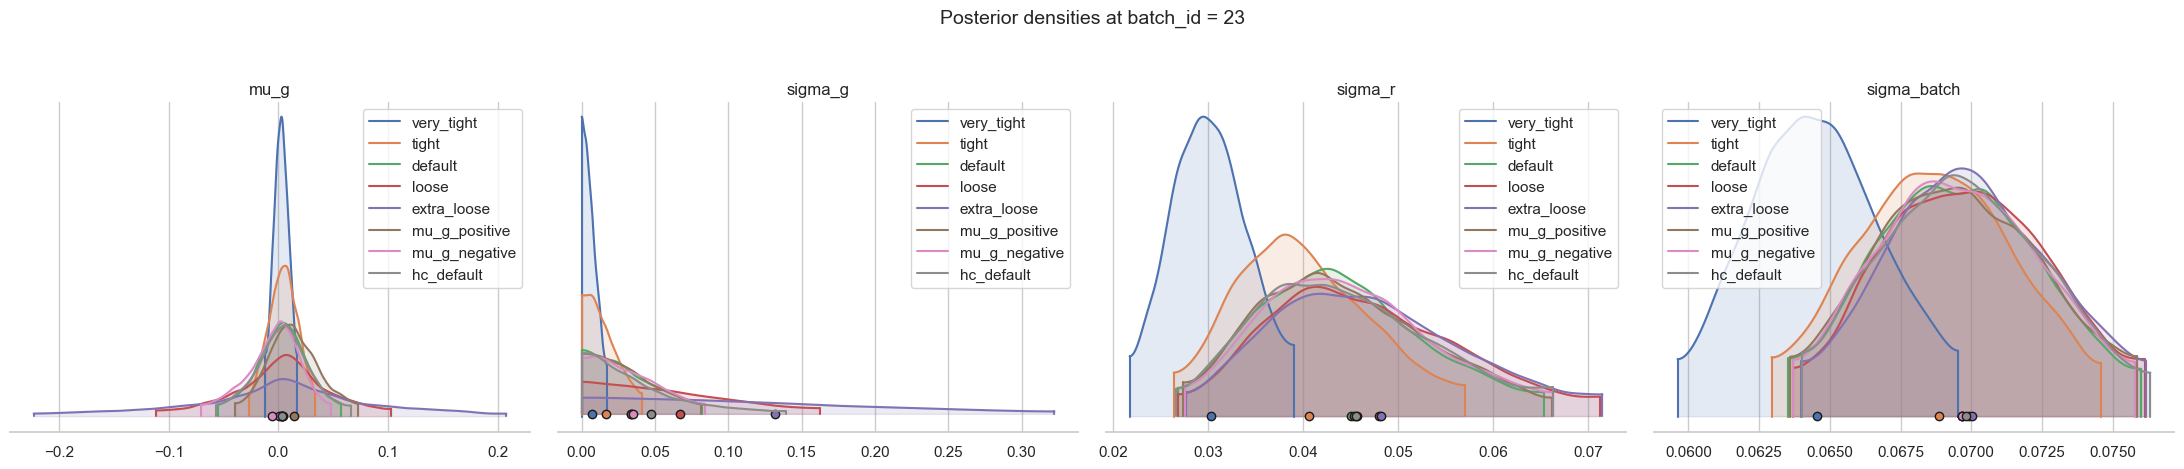

In [71]:
traces_list = [sensitivity_traces[name][last_batch] for name in config_names]

fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))
for ax, var in zip(axes, key_vars):
    az.plot_density(
        traces_list,
        data_labels=config_names,
        var_names=[var],
        ax=ax,
        shade=0.15,
    )
    ax.set_title(var)
plt.suptitle(f'Posterior densities at batch_id = {last_batch}', y=1.04, fontsize=14)
plt.tight_layout()
plt.show()

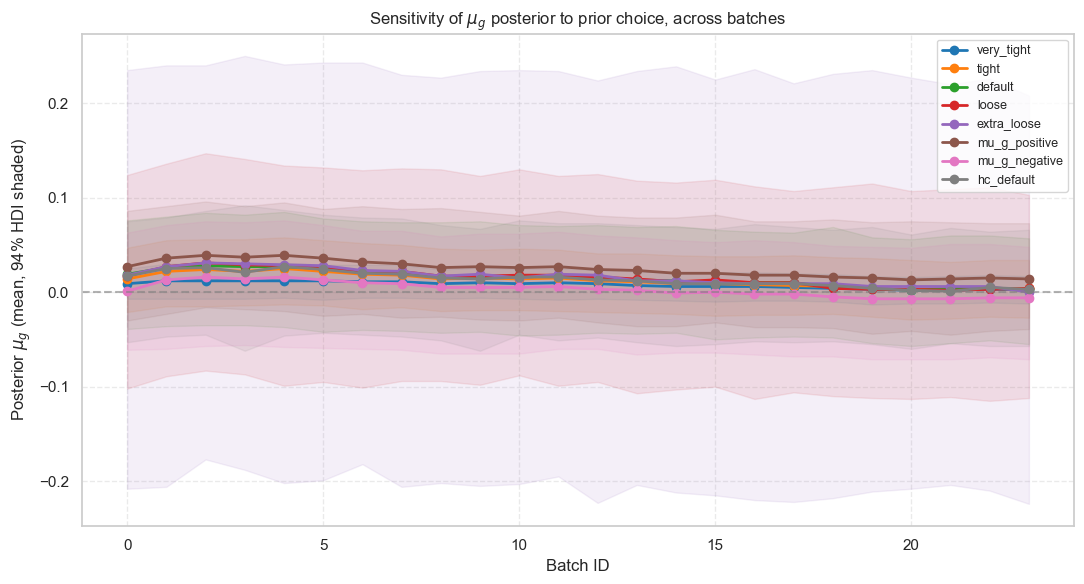

In [72]:
# How does the posterior mean of mu_g evolve across batches, under each scenario?
records = []
for name in config_names:
    for batch in batches:
        s = az.summary(sensitivity_traces[name][batch], var_names=['mu_g'])
        records.append({
            'scenario': name, 'batch_id': batch,
            'mu_g_mean': s['mean'].iloc[0],
            'mu_g_lo':   s['hdi_3%'].iloc[0],
            'mu_g_hi':   s['hdi_97%'].iloc[0],
        })
mu_g_traj = pd.DataFrame(records)

plt.figure(figsize=(11, 6))
palette = sns.color_palette('tab10', n_colors=len(config_names))
for color, name in zip(palette, config_names):
    sub = mu_g_traj[mu_g_traj['scenario'] == name].sort_values('batch_id')
    plt.plot(sub['batch_id'], sub['mu_g_mean'], marker='o', linewidth=2, label=name, color=color)
    plt.fill_between(sub['batch_id'], sub['mu_g_lo'], sub['mu_g_hi'], color=color, alpha=0.10)
plt.axhline(0, color='gray', linestyle='--', alpha=0.6)
plt.xlabel('Batch ID')
plt.ylabel(r'Posterior $\mu_g$ (mean, 94% HDI shaded)')
plt.title('Sensitivity of $\\mu_g$ posterior to prior choice, across batches')
plt.legend(loc='best', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Predictive sensitivity (forward simulation + forecast accuracy)

The v1 likelihood has no batch-size scaling: $b_{r,t}\sim\mathcal{N}(p_r^{(0)} + s_g + s_r, \sigma_{\text{batch}}^2)$. Forward sim uses constant $\sigma_{\text{batch}}$ for all remaining batches.

In [73]:
def extract_thin_posteriors(traces_dict, baseline_array, n_thin=1000):
    out = {}
    for current_batch, trace in traces_dict.items():
        s_r_raw       = trace.posterior['s_r'].values
        s_g_raw       = trace.posterior['s_g'].values
        sig_batch_raw = trace.posterior['sigma_batch'].values
        s_r_flat       = s_r_raw.reshape(-1, s_r_raw.shape[-1])
        s_g_flat       = s_g_raw.flatten()
        sig_batch_flat = sig_batch_raw.flatten()
        total_samples = len(s_g_flat)
        step = max(1, total_samples // n_thin)
        s_r_thin       = s_r_flat[::step][:n_thin]
        s_g_thin       = s_g_flat[::step][:n_thin]
        sig_batch_thin = sig_batch_flat[::step][:n_thin]
        expected_b = s_r_thin + s_g_thin[:, np.newaxis] + baseline_array
        out[current_batch] = {'expected_b': expected_b, 'sigma_batch': sig_batch_thin}
    return out


def run_forward_simulation_v1(extracted, model_data, race_data, batches, n_races,
                              seed=42, concentration_scale=20.0):
    rng = np.random.default_rng(seed=seed)
    final_outcomes = {}
    simulated_future = {}
    total_batches = len(batches)
    for i, current_batch in enumerate(batches):
        n_remaining = total_batches - i - 1
        cumulative_data = model_data[model_data['batch_id'] <= current_batch]
        current_data = cumulative_data.sort_values('batch_id').drop_duplicates(subset=['race_id'], keep='last')
        current_dem_votes = np.zeros(n_races)
        votes_remaining   = np.zeros(n_races)
        current_race_indices = current_data['race_id'].values
        current_dem_votes[current_race_indices] = current_data['up_to_this_batch_dem_votes'].values
        calc_remaining = current_data['final_total_votes'] - current_data['up_to_this_batch_total_votes']
        votes_remaining[current_race_indices] = np.maximum(0, calc_remaining.values)

        if n_remaining > 0:
            log_weights = np.log(1 + 1 / np.arange(1, n_remaining + 1))
            alphas = log_weights * concentration_scale
            dirichlet_draws = rng.dirichlet(alpha=alphas, size=(1000, n_races)).transpose(0, 2, 1)
            sim_batch_sizes = dirichlet_draws * votes_remaining

            exp_b_1000     = extracted[current_batch]['expected_b']
            sig_batch_1000 = extracted[current_batch]['sigma_batch']
            exp_b_reshaped     = exp_b_1000[:, np.newaxis, :]
            sig_batch_reshaped = sig_batch_1000[:, np.newaxis, np.newaxis]

            sim_dem_rates = rng.normal(loc=exp_b_reshaped, scale=sig_batch_reshaped,
                                       size=(1000, n_remaining, n_races))
            sim_dem_rates = np.clip(sim_dem_rates, 0.0, 1.0)
            simulated_future[current_batch] = sim_dem_rates
            added_dem = sim_batch_sizes * sim_dem_rates
            final_outcomes[current_batch] = current_dem_votes + added_dem.sum(axis=1)
        else:
            final_outcomes[current_batch] = np.tile(current_dem_votes, (1000, 1))
            simulated_future[current_batch] = None
    return simulated_future, final_outcomes

In [74]:
extracted_by_cfg   = {}
sim_future_by_cfg  = {}
final_outcome_by_cfg = {}

for name in config_names:
    extracted_by_cfg[name] = extract_thin_posteriors(sensitivity_traces[name], baseline_array)
    sf, fo = run_forward_simulation_v1(extracted_by_cfg[name], model_data, race_data, batches, n_races, seed=42)
    sim_future_by_cfg[name]  = sf
    final_outcome_by_cfg[name] = fo
    print(f'Forward sim done: {name}')

Forward sim done: very_tight
Forward sim done: tight
Forward sim done: default
Forward sim done: loose
Forward sim done: extra_loose
Forward sim done: mu_g_positive
Forward sim done: mu_g_negative
Forward sim done: hc_default


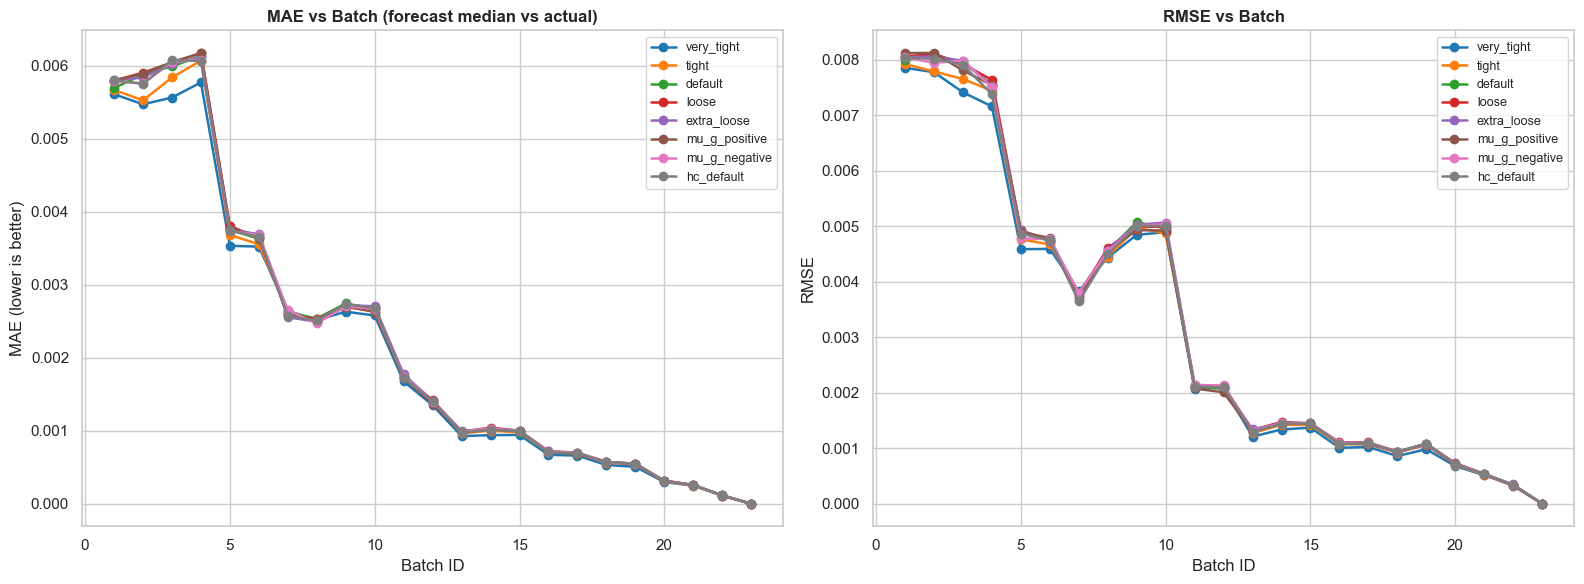

,mean_MAE,mean_RMSE,final_batch_MAE,final_batch_RMSE
scenario,,,,
default,0.00222,0.00321,0.0,0.0
extra_loose,0.00222,0.00321,0.0,0.0
hc_default,0.00221,0.00319,0.0,0.0
loose,0.00223,0.00322,0.0,0.0
mu_g_negative,0.00222,0.00320,0.0,0.0
mu_g_positive,0.00222,0.00319,0.0,0.0
tight,0.00218,0.00315,0.0,0.0
very_tight,0.00212,0.00308,0.0,0.0


In [75]:
actual_final = race_data.sort_values('race_id')['final_dem_proportion'].values
denoms       = race_data.sort_values('race_id')['final_total_votes'].values

records = []
for name in config_names:
    for batch in batches:
        sims = final_outcome_by_cfg[name][batch]
        pred_prop = np.median(sims, axis=0) / denoms
        records.append({
            'scenario': name, 'batch_id': batch,
            'MAE':  float(np.mean(np.abs(pred_prop - actual_final))),
            'RMSE': float(np.sqrt(np.mean((pred_prop - actual_final) ** 2))),
        })
err = pd.DataFrame(records)
err = err[err['batch_id'] != 0].copy()

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = sns.color_palette('tab10', n_colors=len(config_names))
for color, name in zip(palette, config_names):
    sub = err[err['scenario'] == name].sort_values('batch_id')
    axes[0].plot(sub['batch_id'], sub['MAE'],  marker='o', linewidth=1.8, label=name, color=color)
    axes[1].plot(sub['batch_id'], sub['RMSE'], marker='o', linewidth=1.8, label=name, color=color)
axes[0].set_title('MAE vs Batch (forecast median vs actual)', fontweight='bold')
axes[0].set_xlabel('Batch ID'); axes[0].set_ylabel('MAE (lower is better)')
axes[1].set_title('RMSE vs Batch', fontweight='bold')
axes[1].set_xlabel('Batch ID'); axes[1].set_ylabel('RMSE')
axes[0].legend(fontsize=9, loc='best')
axes[1].legend(fontsize=9, loc='best')
plt.tight_layout()
plt.show()

# Aggregate over batches
agg = err.groupby('scenario').agg(
    mean_MAE = ('MAE',  'mean'),
    mean_RMSE = ('RMSE', 'mean'),
    final_batch_MAE  = ('MAE',  lambda x: x.iloc[-1] if len(x) else np.nan),
    final_batch_RMSE = ('RMSE', lambda x: x.iloc[-1] if len(x) else np.nan),
).round(5)
display(agg)

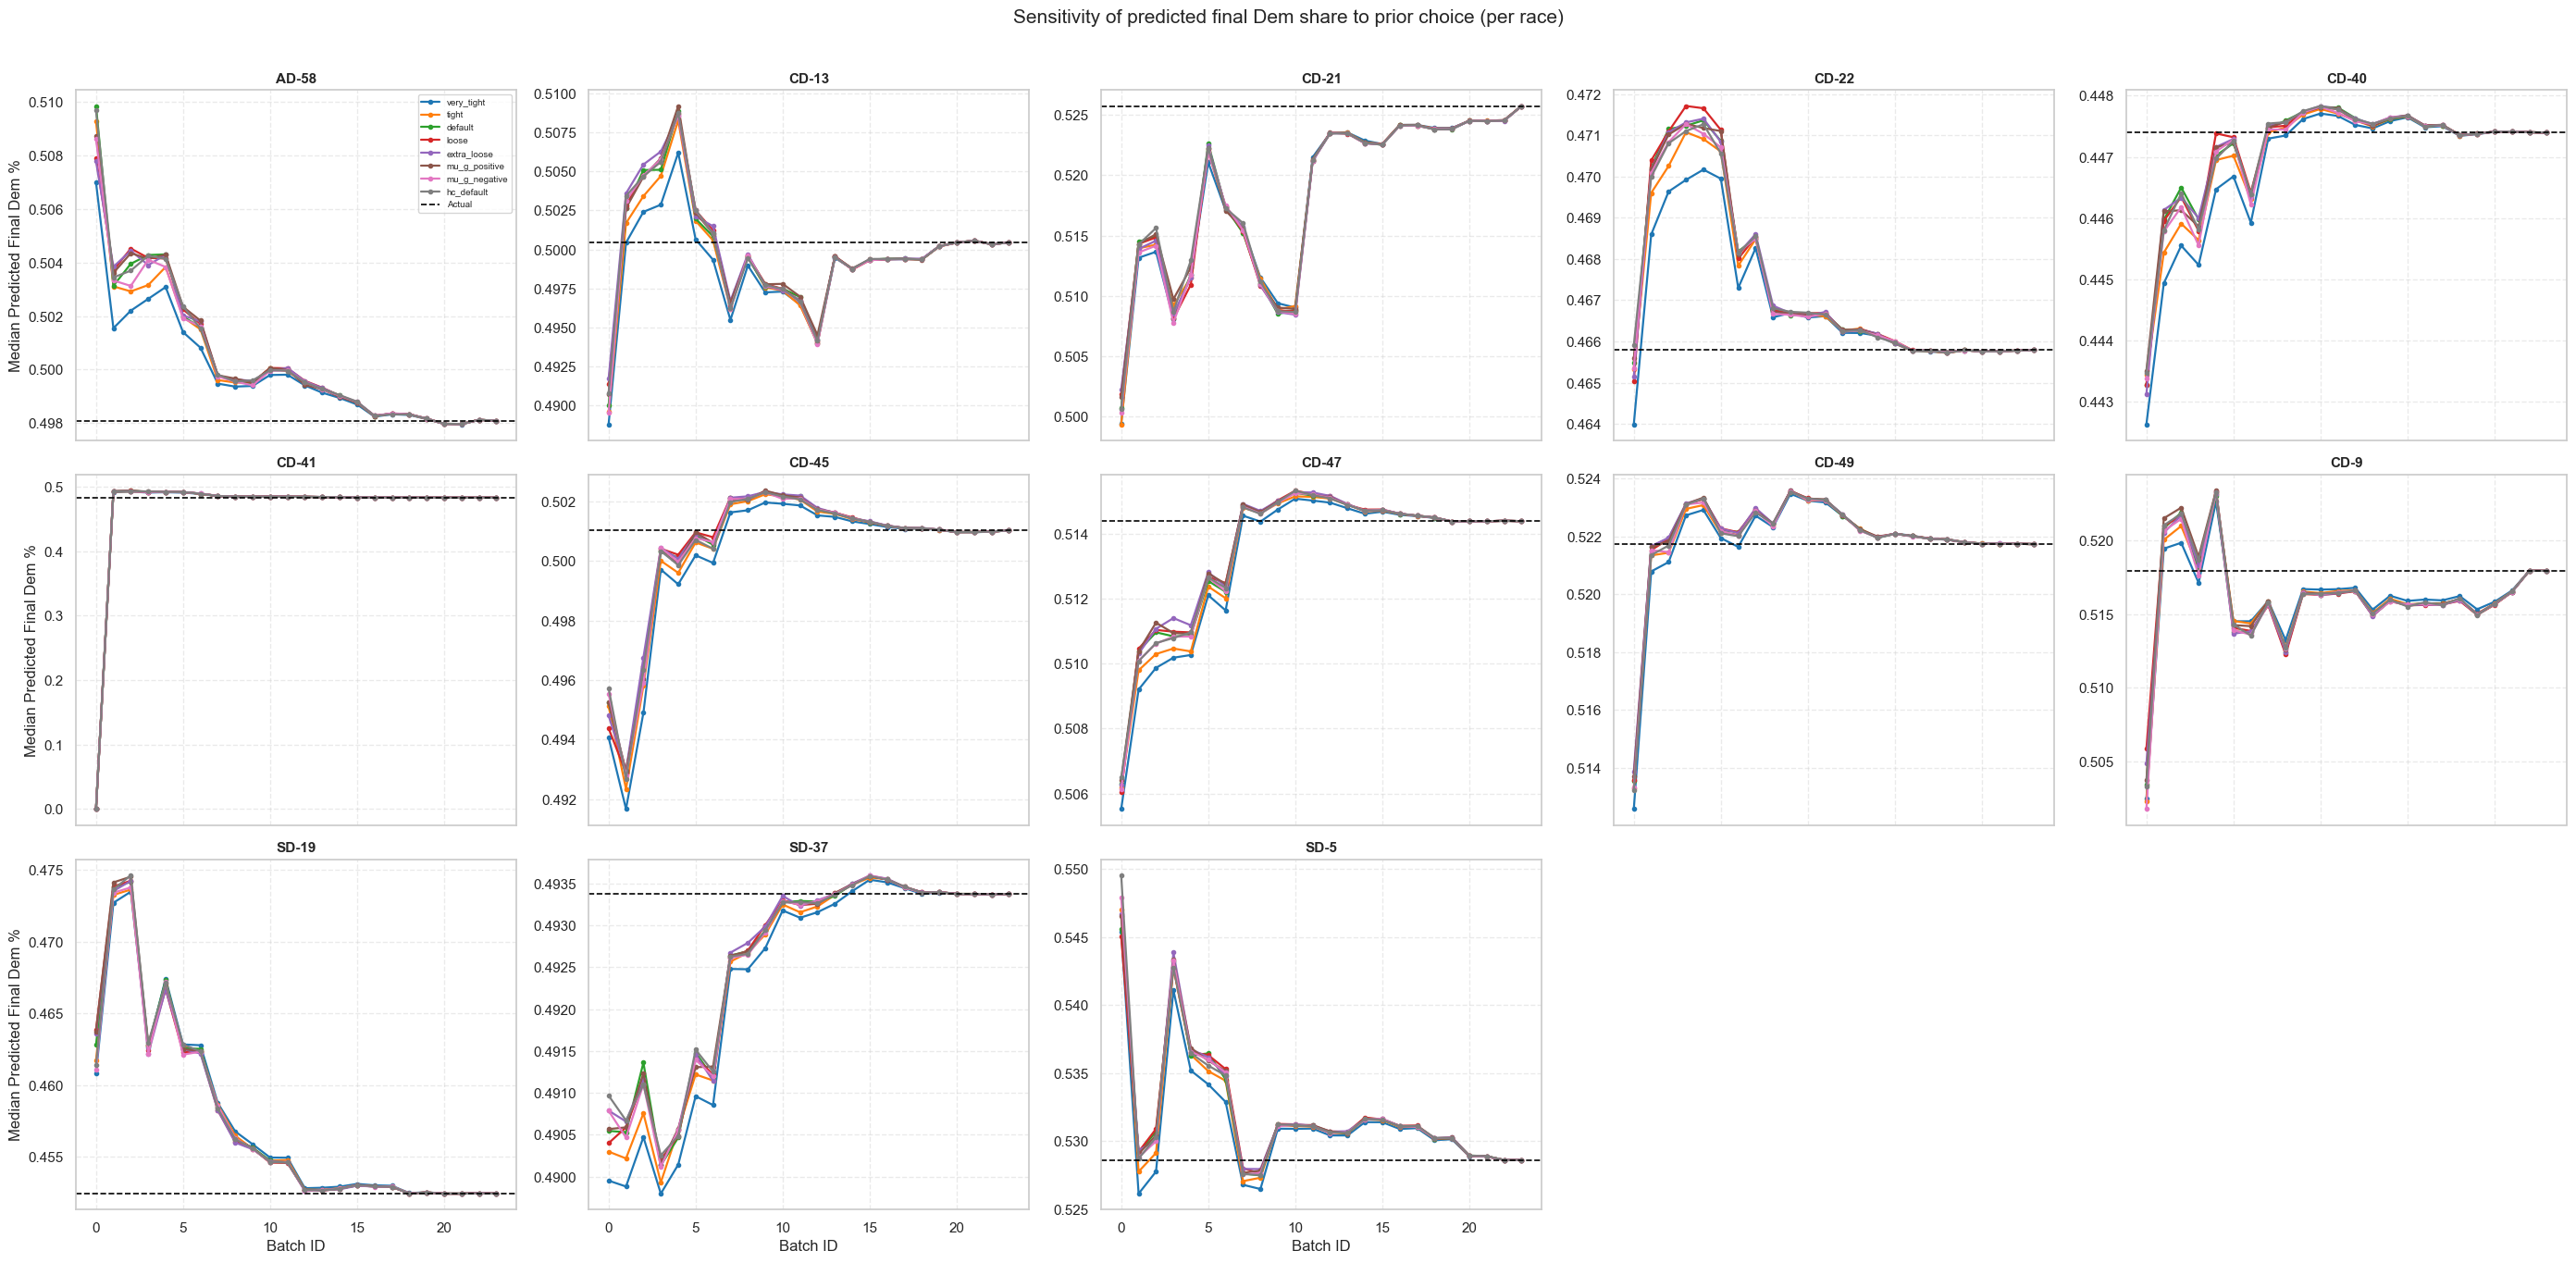

In [76]:
# Per-race predicted final Dem share across batches, overlay all scenarios
races_to_plot = sorted(range(n_races))
cols = 5
rows = int(np.ceil(len(races_to_plot) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(28, 4.5 * rows), sharex=True)
axes = axes.flatten()
palette = sns.color_palette('tab10', n_colors=len(config_names))

for ax_idx, race_idx in enumerate(races_to_plot):
    ax = axes[ax_idx]
    race_name = id_to_race[race_idx]
    denom = denoms[race_idx]
    actual = actual_final[race_idx]
    for color, name in zip(palette, config_names):
        med = [np.median(final_outcome_by_cfg[name][b][:, race_idx]) / denom for b in batches]
        ax.plot(batches, med, marker='.', linewidth=1.6, label=name, color=color)
    ax.axhline(actual, color='black', linestyle='--', linewidth=1.2, label='Actual')
    ax.set_title(race_name, fontsize=11, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)
    if ax_idx % cols == 0: ax.set_ylabel('Median Predicted Final Dem %')
    if ax_idx >= (rows - 1) * cols: ax.set_xlabel('Batch ID')

for i in range(len(races_to_plot), len(axes)):
    fig.delaxes(axes[i])
axes[0].legend(fontsize=7, loc='best')
plt.suptitle('Sensitivity of predicted final Dem share to prior choice (per race)', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## Sensitivity summary metric

For each hyperparameter we extract the posterior mean at the **final batch** under every scenario and summarize how much it moves. The table answers: *is this parameter data-dominated (posterior barely changes across priors) or prior-dominated (posterior tracks the prior)?*

---

### Column definitions

| Column | Formula | What it measures |
|---|---|---|
| `default_mean` | posterior mean under `default` | your baseline estimate |
| `min_mean` / `max_mean` | min / max of posterior means across all scenarios | the extremes of where the posterior can land |
| `range` | `max_mean − min_mean` | raw spread of posterior means; same units as the parameter |
| `sd_across_configs` | std of posterior means across scenarios | more robust spread measure (less driven by a single outlier scenario) |
| `relative_range` | `range / \|default_mean\|` | spread normalized by the size of the default estimate |

---

### How to interpret `range` and `sd_across_configs`

These measure **how much the posterior location shifts** as you vary the prior. A small value means the data are strong enough to pull every prior toward the same answer — the likelihood dominates. A large value means the posterior is still sensitive to where you started, which is a signal that the data alone are not very informative about that parameter.

- **`sigma_batch`**: range ≈ 0.001 (near zero). Every scenario gives essentially the same posterior. This makes sense — `sigma_batch` is directly observable as the residual scatter of batch proportions around the predicted mean, and 13 × 24 observations pin it tightly regardless of prior.
- **`sigma_r`**: range ≈ 0.007. Small but non-negligible. The 13 race-level shifts provide moderate information about the cross-race variance, so the prior still has a modest influence.
- **`mu_g`**: range ≈ 0.02. In absolute terms this is small (2 percentage points), but see the `relative_range` caveat below.
- **`sigma_g`**: range can be larger because `sigma_g` is weakly identified — it controls the *within-election* variation in the global shift, which is a single scalar inferred from a single election. The data constrain it less than `sigma_r` or `sigma_batch`.

---

### How to interpret `relative_range`

`relative_range = range / |default_mean|`. It answers: *the spread is what fraction of the default estimate?* A value near 0 means robust; a value much greater than 1 means sensitive.

**Caveat — near-zero parameters**: `mu_g` has a default posterior mean very close to zero (~0.003). Even a tiny absolute range (0.02) produces a huge `relative_range` (~7). This is not meaningful — it just reflects that zero is in the denominator, not that `mu_g` is dangerously sensitive. For near-zero parameters, trust `range` and `sd_across_configs` instead of `relative_range`.

**Rule of thumb:**
- `relative_range < 0.2` → data-dominated, robust to prior choice
- `0.2 – 1.0` → moderate sensitivity; worth reporting the range
- `> 1.0` → prior-dominated (or near-zero denominator issue); interpret with care

---

### Overall takeaway

A parameter being *prior-dominated* is not necessarily a problem — it just means your data cannot strongly identify it. The important question is whether the **forecasts and downstream conclusions** change across scenarios. If MAE/RMSE curves and per-race predictions are stable even when `sigma_g` varies widely, the model is functionally robust even if that one hyperparameter is not. Use the MAE/RMSE and per-race plots above to assess that.

=== Final batch ===


,parameter,range,sd_across_configs,relative_range,default_mean
92,mu_g,0.020,0.00551,6.66667,0.003
93,sigma_g,0.125,0.03892,3.67647,0.034
94,sigma_r,0.018,0.00593,0.40000,0.045
95,sigma_batch,0.005,0.00175,0.07143,0.070


=== Average across all batches ===


,avg_relative_range,avg_sd_across_configs,avg_range
parameter,,,
mu_g,2.52085,0.00653,0.02204
sigma_g,3.61092,0.03875,0.12321
sigma_r,0.39725,0.00519,0.01588
sigma_batch,0.14322,0.00258,0.00771


  Note: avg_relative_range for mu_g is unreliable (denominator near zero).
        Use avg_sd_across_configs / avg_range for mu_g instead.


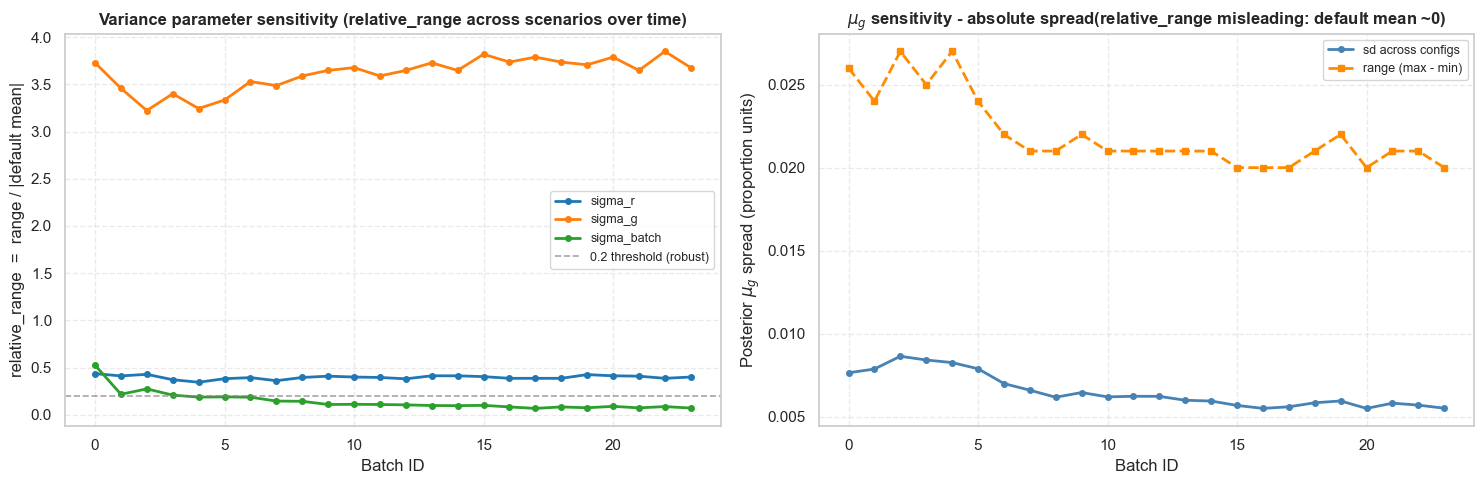

Interpretation:
  Variance params : relative_range < 0.2 => data-dominated, robust to prior choice
  mu_g            : sd / range in proportion units; 0.01 ~ 1 pp of Dem share


In [93]:
variance_params = ["sigma_r", "sigma_g", "sigma_batch"]

# Compute metrics over every batch
records = []
for batch in batches:
    for var in key_vars:
        means = np.array([
            az.summary(sensitivity_traces[name][batch], var_names=[var])["mean"].iloc[0]
            for name in config_names
        ])
        default_mean = means[config_names.index("default")]
        records.append({
            "batch_id":          batch,
            "parameter":         var,
            "range":             float(means.max() - means.min()),
            "sd_across_configs": float(means.std(ddof=1)),
            "relative_range":    float((means.max() - means.min()) / max(abs(default_mean), 1e-6)),
        })
sens_time = pd.DataFrame(records)

# Final-batch summary
print("=== Final batch ===")
last_rows = sens_time[sens_time["batch_id"] == last_batch][
    ["parameter", "range", "sd_across_configs", "relative_range"]
].copy()
last_rows["default_mean"] = [
    az.summary(sensitivity_traces["default"][last_batch], var_names=[v])["mean"].iloc[0]
    for v in key_vars
]
display(last_rows.round(5))

# Average across all batches
print("=== Average across all batches ===")
avg_rows = sens_time.groupby("parameter").agg(
    avg_relative_range   = ("relative_range",    "mean"),
    avg_sd_across_configs= ("sd_across_configs", "mean"),
    avg_range            = ("range",             "mean"),
).reindex(key_vars).round(5)
avg_rows.index.name = "parameter"
display(avg_rows)
print("  Note: avg_relative_range for mu_g is unreliable (denominator near zero).")
print("        Use avg_sd_across_configs / avg_range for mu_g instead.")

# Over-batch sensitivity plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
palette = sns.color_palette("tab10", n_colors=len(variance_params))

ax = axes[0]
for color, var in zip(palette, variance_params):
    sub = sens_time[sens_time["parameter"] == var].sort_values("batch_id")
    ax.plot(sub["batch_id"], sub["relative_range"], marker="o", markersize=4,
            linewidth=2, label=var, color=color)
ax.axhline(0.2, color="gray", linestyle="--", linewidth=1.2, alpha=0.7, label="0.2 threshold (robust)")
ax.set_xlabel("Batch ID")
ax.set_ylabel("relative_range  =  range / |default mean|")
ax.set_title("Variance parameter sensitivity (relative_range across scenarios over time)",
             fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, linestyle="--", alpha=0.4)

ax = axes[1]
sub = sens_time[sens_time["parameter"] == "mu_g"].sort_values("batch_id")
ax.plot(sub["batch_id"], sub["sd_across_configs"], marker="o", markersize=4,
        linewidth=2, color="steelblue", label="sd across configs")
ax.plot(sub["batch_id"], sub["range"], marker="s", markersize=4,
        linewidth=2, linestyle="--", color="darkorange", label="range (max - min)")
ax.set_xlabel("Batch ID")
ax.set_ylabel(r"Posterior $\mu_g$ spread (proportion units)")
ax.set_title(r"$\mu_g$ sensitivity - absolute spread" +
             "(relative_range misleading: default mean ~0)", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

print("Interpretation:")
print("  Variance params : relative_range < 0.2 => data-dominated, robust to prior choice")
print("  mu_g            : sd / range in proportion units; 0.01 ~ 1 pp of Dem share")

In [81]:
out_root = 'v1_sensitivity_traces'
os.makedirs(out_root, exist_ok=True)
for name in config_names:
    out_dir = os.path.join(out_root, name)
    os.makedirs(out_dir, exist_ok=True)
    for current_batch in batches:
        fp = os.path.join(out_dir, f'trace_batch_{current_batch}.nc')
        if os.path.exists(fp):
            os.remove(fp)
        sensitivity_traces[name][current_batch].to_netcdf(fp)
    print(f'Saved {len(batches)} traces -> {out_dir}/')

PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: 'v1_sensitivity_traces\\very_tight\\trace_batch_0.nc'